# Zero-Inflated Gamma (ZIG) Precipitation Model

A single-model replacement for the two-stage SSWM from Anderson et al. (2016).  
Instead of separate occurrence and intensity models, one MLP jointly outputs:

| Head | Output | Constraint | Meaning |
|------|--------|------------|---------|
| `logit_p` | scalar | sigmoid → (0,1) | P(wet\|x) |
| `alpha` | K values | softplus > 0 | gamma shape per component |
| `beta` | K values | softplus > 0 | gamma rate per component |
| `pi` | K values | softmax → sum=1 | mixture weights (K=1: pure gamma; K=2: gamma-gamma) |

**Joint NLL loss** — no separate training loops:

$$\mathcal{L} = -\frac{1}{N}\sum_n \left[ \mathbb{1}_{y_n=0}\log(1-p_n) + \mathbb{1}_{y_n>0}\left(\log p_n + \log\sum_k \pi_k \,\Gamma(y_n;\alpha_k,\beta_k)\right)\right]$$

Set `n_components=1` for simple ZIG-Gamma, `n_components=2` for the paper's gamma-gamma form.

## 1. Imports

In [1]:
from __future__ import annotations

import math
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(71)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Feature engineering

Extends the SSWM feature set by adding lagged intensity alongside lagged occurrence:

- **Day-of-year** encoded as (sin, cos) pair for smooth, boundary-free seasonality
- **L lagged occurrence indicators** — binary, col 0 = oldest (t−L), col −1 = yesterday (t−1)
- **L_int lagged intensity values** — log1p-transformed mm, same window convention; zero on dry days maps cleanly to log1p(0) = 0
- **Optional extra covariates** (SST indices, etc.) appended as-is

`N_INT_LAGS` in §8 controls `L_int`; set it to 0 to reproduce the occurrence-only SSWM feature space.

In [2]:
def doy_encoding(doy: torch.Tensor) -> torch.Tensor:
    """Integer day-of-year [1..365] → (sin, cos) pair, shape (N, 2)."""
    angle = 2.0 * math.pi * (doy.float() - 1.0) / 365.0
    return torch.stack([angle.sin(), angle.cos()], dim=-1)


def compute_in_features(
    n_lags: int, n_int_lags: int = 0, n_extra: int = 0
) -> int:
    """Return input feature dimension: 2 (doy) + n_lags [+ n_int_lags] [+ n_extra]."""
    return 2 + n_lags + n_int_lags + n_extra


def build_features(
    doy: np.ndarray,                        # (N,)   int, day-of-year 1..365
    occ_lags: np.ndarray,                   # (N, L) float32, lagged occurrence
    int_lags: Optional[np.ndarray] = None,  # (N, L) float32, lagged intensity mm
    extra: Optional[np.ndarray] = None,     # (N, E) optional covariates
) -> torch.Tensor:
    """Assemble float32 input tensor, shape (N, 2 + L [+ L_int] [+ E]).

    Lagged intensities are log1p-transformed before concatenation so that
    dry-day zeros map cleanly to 0 and the right-skewed wet-day values are
    compressed to a model-friendly range.
    """
    doy_enc = doy_encoding(torch.from_numpy(np.asarray(doy, dtype=np.int32)))
    parts = [doy_enc, torch.from_numpy(np.asarray(occ_lags, dtype=np.float32))]
    if int_lags is not None:
        log1p_int = np.log1p(np.asarray(int_lags, dtype=np.float32))
        parts.append(torch.from_numpy(log1p_int))
    if extra is not None:
        parts.append(torch.from_numpy(np.asarray(extra, dtype=np.float32)))
    return torch.cat(parts, dim=-1)

## 3. Model

Single shared trunk, three output heads.  
The joint ZIG-Gamma(-Gamma) parameterisation eliminates the two-stage split.

In [3]:
class ZIGammaMLP(nn.Module):
    """Zero-Inflated Gamma (mixture) MLP.

    A single network jointly estimates:
        P(wet | x)  via logit_p head
        p(y | wet, x) via a K-component gamma mixture (alpha, beta, pi heads)

    Parameters
    ----------
    in_features   : input dimension from build_features()
    hidden_sizes  : MLP hidden layer widths
    n_components  : K=1 → simple ZIG-Gamma; K=2 → gamma-gamma (paper form)
    dropout       : applied after each hidden layer
    """

    def __init__(
        self,
        in_features: int,
        hidden_sizes: Tuple[int, ...] = (64, 64),
        n_components: int = 1,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.K = n_components

        # Shared feature extractor
        layers: list[nn.Module] = []
        prev = in_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h), nn.LayerNorm(h),
                nn.ReLU(), nn.Dropout(dropout),
            ]
            prev = h
        self.trunk = nn.Sequential(*layers)

        # Output heads
        self.head_logit_p = nn.Linear(prev, 1)            # → logit P(wet)
        self.head_alpha   = nn.Linear(prev, n_components)  # → gamma shape
        self.head_beta    = nn.Linear(prev, n_components)  # → gamma rate
        self.head_pi      = nn.Linear(prev, n_components)  # → mixing weights

    def forward(
        self, x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns
        -------
        logit_p : (N, 1)   raw logit for P(wet)
        pi      : (N, K)   mixture weights, sum-to-1
        alpha   : (N, K)   gamma shape > 0
        beta    : (N, K)   gamma rate  > 0
        """
        h = self.trunk(x)
        logit_p = self.head_logit_p(h)                          # (N, 1)
        pi      = F.softmax(self.head_pi(h), dim=-1)            # (N, K)
        alpha   = F.softplus(self.head_alpha(h)) + 1e-3         # (N, K)
        beta    = F.softplus(self.head_beta(h))  + 1e-3         # (N, K)
        return logit_p, pi, alpha, beta

    @torch.no_grad()
    def p_wet(self, x: torch.Tensor) -> torch.Tensor:
        """P(wet | x), shape (N,). Convenience method for calibration."""
        logit_p, *_ = self.forward(x)
        return torch.sigmoid(logit_p).squeeze(-1)

## 4. Joint NLL loss

Handles the zero-inflation in a single expression:  
dry days contribute only via `log(1 − p)`; wet days contribute via `log(p)` **+** gamma log-likelihood.

In [4]:
def _gamma_log_prob(
    y: torch.Tensor,      # (M,)    positive values only
    alpha: torch.Tensor,  # (M, K)
    beta: torch.Tensor,   # (M, K)
) -> torch.Tensor:
    """Log-density under each gamma component (rate parameterisation).

    log p(y | α, β) = α·log β − log Γ(α) + (α−1)·log y − β·y

    Returns (M, K).
    """
    y_ = y.unsqueeze(-1)  # (M, 1) — broadcasts over K
    return (
        alpha * beta.log()
        - torch.lgamma(alpha)
        + (alpha - 1.0) * y_.clamp(min=1e-6).log()
        - beta * y_
    )


def zig_nll(
    logit_p: torch.Tensor,  # (N, 1)
    pi: torch.Tensor,       # (N, K)
    alpha: torch.Tensor,    # (N, K)
    beta: torch.Tensor,     # (N, K)
    y: torch.Tensor,        # (N,)   full record (0 on dry days)
    wet_threshold: float = 1.0,
) -> torch.Tensor:
    """Joint zero-inflated gamma NLL — single loss for the whole record.

    Dry days  (y < threshold):  -log(1 − sigmoid(logit_p))
    Wet days  (y ≥ threshold):  -log(sigmoid(logit_p))
                                -log Σ_k π_k · Gamma(y; α_k, β_k)

    Uses F.logsigmoid for numerical stability on both branches.
    """
    is_wet = y >= wet_threshold          # (N,) bool mask

    logit_p = logit_p.squeeze(-1)        # (N,)
    log_p   = F.logsigmoid(logit_p)      # log P(wet)
    log_1mp = F.logsigmoid(-logit_p)     # log P(dry) = log(1 − sigmoid)

    # Dry contribution
    loss_dry = -log_1mp[~is_wet].sum()

    # Wet contribution: log P(wet) + log mixture density
    if is_wet.any():
        lp = _gamma_log_prob(y[is_wet], alpha[is_wet], beta[is_wet])  # (M, K)
        log_mix = torch.logsumexp(pi[is_wet].log() + lp, dim=-1)      # (M,)
        loss_wet = -(log_p[is_wet] + log_mix).sum()
    else:
        loss_wet = torch.tensor(0.0, device=y.device)

    return (loss_dry + loss_wet) / len(y)

## 5. Training — one loop

Pass the **training** record (zeros included). The validation split is defined in §8.

`train_zig()` accepts optional `x_val` / `y_val` tensors. When supplied it:

1. Evaluates the joint NLL on the validation set after every epoch.
2. Keeps a running best-weight checkpoint whenever the validation NLL improves by more than `min_delta`.
3. Halts when no improvement has been seen for `patience` epochs and restores the best checkpoint before returning.

The returned `history` dict contains `"train"` and `"val"` NLL lists and `"best_epoch"` for the loss-curve cell.

In [5]:
def train_zig(
    model: ZIGammaMLP,
    x: torch.Tensor,                          # (N, F)  training days
    y: torch.Tensor,                          # (N,)    float32, 0 on dry days
    x_val: Optional[torch.Tensor] = None,     # (M, F)  validation days
    y_val: Optional[torch.Tensor] = None,     # (M,)    float32, 0 on dry days
    n_epochs: int = 300,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    wet_threshold: float = 1.0,               # mm, consistent with Anderson et al.
    patience: int = 50,                       # early-stop epochs without improvement
    min_delta: float = 1e-4,                  # minimum drop in val NLL to count
    device: str = "cpu",
) -> dict[str, list[float]]:
    """Train the ZIG model, optionally with early stopping on a held-out record.

    If ``x_val`` / ``y_val`` are supplied the function evaluates the validation
    NLL after every epoch.  Training halts when the validation loss has not
    improved by more than ``min_delta`` for ``patience`` consecutive epochs, and
    the best-weight checkpoint is restored before returning.

    Returns
    -------
    history : dict with keys ``"train"`` and (if val data provided) ``"val"``,
              each a list of per-epoch mean NLL values.  ``history["best_epoch"]``
              records the epoch at which the best validation NLL was achieved.
    """
    model.to(device)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=n_epochs)
    loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)

    use_val = (x_val is not None) and (y_val is not None)
    train_hist: list[float] = []
    val_hist:   list[float] = []

    best_val_nll  = float("inf")
    best_epoch    = 0
    best_state    = None
    epochs_no_imp = 0

    for epoch in range(n_epochs):
        # ── Training pass ──────────────────────────────────────────────────────
        model.train()
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            logit_p, pi, alpha, beta = model(xb)
            loss = zig_nll(logit_p, pi, alpha, beta, yb, wet_threshold)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(xb)
        scheduler.step()
        train_nll = running / len(x)
        train_hist.append(train_nll)

        # ── Validation pass ────────────────────────────────────────────────────
        if use_val:
            model.eval()
            with torch.no_grad():
                xv = x_val.to(device)
                yv = y_val.to(device)
                lp, pi_v, al, be = model(xv)
                val_nll = zig_nll(lp, pi_v, al, be, yv, wet_threshold).item()
            val_hist.append(val_nll)

            # Check for improvement
            if val_nll < best_val_nll - min_delta:
                best_val_nll  = val_nll
                best_epoch    = epoch + 1
                best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_imp = 0
            else:
                epochs_no_imp += 1

        # ── Progress print ─────────────────────────────────────────────────────
        if (epoch + 1) % 10 == 0:
            val_str = f"  val NLL={val_hist[-1]:.4f}" if use_val else ""
            print(f"  epoch {epoch + 1:4d}/{n_epochs}  train NLL={train_nll:.4f}{val_str}")

        # ── Early stopping ─────────────────────────────────────────────────────
        if use_val and epochs_no_imp >= patience:
            print(
                f"  Early stop at epoch {epoch + 1} "
                f"(best val NLL={best_val_nll:.4f} at epoch {best_epoch})"
            )
            break

    # Restore best checkpoint if we were tracking validation loss
    if use_val and best_state is not None:
        model.load_state_dict(best_state)

    history: dict[str, list[float] | int] = {"train": train_hist}
    if use_val:
        history["val"]        = val_hist
        history["best_epoch"] = best_epoch
    return history

## 6. Monte Carlo forward simulation

Equivalent to the 1 000-member ensemble in Anderson et al. (2016) §2c, with two
extensions enabled by the single-model design:

1. **One forward pass per time step** — occurrence and intensity parameters are
   computed jointly, replacing the two sequential model calls of the original SSWM.
2. **Dual lag buffers** — both the occurrence history and the intensity history are
   rolled forward at each step, so the simulated sequences condition on their own
   past intensities exactly as the training data did.

In [6]:
def _sample_gamma_mixture(
    pi: torch.Tensor,    # (N, K)
    alpha: torch.Tensor, # (N, K)
    beta: torch.Tensor,  # (N, K)
) -> torch.Tensor:
    """Draw one sample per row from the gamma mixture. Returns shape (N,).

    1. Pick component k ~ Categorical(pi)
    2. Draw x ~ Gamma(alpha_k, rate=beta_k)
    """
    k = torch.multinomial(pi, num_samples=1).squeeze(-1)   # (N,)
    idx = torch.arange(len(pi), device=pi.device)
    return torch.distributions.Gamma(
        concentration=alpha[idx, k], rate=beta[idx, k]
    ).sample()


@torch.no_grad()
def monte_carlo_simulate(
    model: ZIGammaMLP,
    doy_sequence: np.ndarray,                      # (T,) day-of-year
    n_lags: int = 5,
    n_int_lags: int = 0,                           # number of intensity lags
    extra_sequence: Optional[np.ndarray] = None,   # (T, E)
    n_simulations: int = 1000,
    wet_threshold: float = 1.0,
    device: str = "cpu",
) -> Tuple[np.ndarray, np.ndarray]:
    """Forward-integrate the ZIG model for ``n_simulations`` realisations.

    Equivalent to the 1000-member MC ensemble in Anderson et al. (2016) Sec. 2c,
    but with a single model call per time step instead of two.

    Returns
    -------
    occ_sim : (n_simulations, T)  binary occurrence
    int_sim : (n_simulations, T)  intensity in mm/event (0 on dry days)
    """
    model.eval().to(device)
    T, S = len(doy_sequence), n_simulations
    occ_sim = np.zeros((S, T), dtype=np.float32)
    int_sim = np.zeros((S, T), dtype=np.float32)

    # Initialise lag buffers to all-zero (dry / zero-intensity start)
    lag_buffer = np.zeros((S, n_lags), dtype=np.float32)
    int_lag_buffer = np.zeros((S, n_int_lags), dtype=np.float32) if n_int_lags > 0 else None

    for t in range(T):
        doy_t   = np.full(S, doy_sequence[t], dtype=np.int32)
        extra_t = (
            np.tile(extra_sequence[t], (S, 1)) if extra_sequence is not None else None
        )
        x_t = build_features(
            doy_t, lag_buffer, int_lag_buffer, extra_t
        ).to(device)  # (S, F)

        # Single forward pass → both occurrence and intensity parameters
        logit_p, pi, alpha, beta = model(x_t)

        # Stochastic occurrence draw
        wet_draw = torch.bernoulli(torch.sigmoid(logit_p).squeeze(-1)).cpu().numpy()
        occ_sim[:, t] = wet_draw

        # Intensity only for simulated wet days
        wet_mask = wet_draw.astype(bool)
        if wet_mask.any():
            samples = _sample_gamma_mixture(
                pi[wet_mask], alpha[wet_mask], beta[wet_mask]
            ).cpu().numpy()
            int_sim[wet_mask, t] = np.maximum(samples, wet_threshold)

        # Roll occurrence lag buffer: shift left, append today
        lag_buffer = np.roll(lag_buffer, shift=-1, axis=1)
        lag_buffer[:, -1] = wet_draw  # most-recent lag in last column

        # Roll intensity lag buffer with simulated intensity (log1p applied in build_features)
        if int_lag_buffer is not None:
            int_lag_buffer = np.roll(int_lag_buffer, shift=-1, axis=1)
            int_lag_buffer[:, -1] = int_sim[:, t]  # raw mm; log1p applied in build_features

    return occ_sim, int_sim

## 7. Calibration checks

Three diagnostics matching the paper's evaluation targets.

In [7]:
def reliability_diagram(
    prob_pred: np.ndarray,   # (N,)  predicted P(wet)
    y_obs: np.ndarray,       # (N,)  observed 0/1
    n_bins: int = 10,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Returns (bin_centres, observed_freq, bin_counts), each shape (n_bins,).

    A perfectly calibrated model lies on the diagonal.
    """
    edges   = np.linspace(0.0, 1.0, n_bins + 1)
    centres = np.empty(n_bins)
    freqs   = np.zeros(n_bins)
    counts  = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        mask = (prob_pred >= edges[i]) & (prob_pred < edges[i + 1])
        counts[i] = mask.sum()
        if counts[i] > 0:
            centres[i] = prob_pred[mask].mean()
            freqs[i]   = (y_obs[mask] >= 1.0).mean()
        else:
            centres[i] = (edges[i] + edges[i + 1]) / 2.0
    return centres, freqs, counts


def expected_calibration_error(
    centres: np.ndarray,
    freqs: np.ndarray,
    counts: np.ndarray,
) -> float:
    """Weighted mean |predicted − observed|. ECE=0 is perfect; aim for <0.05."""
    n = counts.sum()
    if n == 0:
        return float("nan")
    return float(np.sum(counts * np.abs(centres - freqs)) / n)


@torch.no_grad()
def intensity_qq_stats(
    model: ZIGammaMLP,
    x_wet: torch.Tensor,    # (M, F)  features on wet days only
    y_obs: np.ndarray,      # (M,)    observed wet-day intensities
    n_quantiles: int = 50,
    device: str = "cpu",
) -> Tuple[np.ndarray, np.ndarray]:
    """Q-Q pairs for intensity calibration.

    Draws one predicted sample per observed wet day and compares quantiles.
    Well-calibrated model → points near the 1:1 line.
    Returns (q_obs, q_pred), each shape (n_quantiles,).
    """
    model.eval().to(device)
    _, pi, alpha, beta = model(x_wet.to(device))
    pred_samples = _sample_gamma_mixture(pi, alpha, beta).cpu().numpy()
    q = np.linspace(0.02, 0.98, n_quantiles)
    return np.quantile(y_obs, q), np.quantile(pred_samples, q)


def annual_metrics(
    occ_sim: np.ndarray,   # (S, T_sim)
    int_sim: np.ndarray,   # (S, T_sim)  0 on dry days
    occ_obs: np.ndarray,   # (T_obs,)
    int_obs: np.ndarray,   # (T_obs,)    0 on dry days
    days_per_year: int = 365,
) -> dict:
    """OCC / SII / TOT comparison: obs vs. ensemble mean ± 1σ.

    Replicates the three diagnostics used throughout Anderson et al. (2016).
    Sim and obs are annualized independently, so their lengths need not match.
    """
    n_years_sim = max(1, occ_sim.shape[1] // days_per_year)
    n_years_obs = max(1, len(occ_obs) // days_per_year)

    occ_s = occ_sim.sum(axis=1) / n_years_sim
    acc_s = int_sim.sum(axis=1) / n_years_sim
    occ_o = occ_obs.sum() / n_years_obs
    acc_o = int_obs.sum() / n_years_obs
    sii_s = np.where(occ_s > 0, acc_s / occ_s, 0.0)
    sii_o = acc_o / occ_o if occ_o > 0 else 0.0

    out: dict = {}
    for name, sim_v, obs_v in [
        ("OCC", occ_s, occ_o),
        ("SII", sii_s, sii_o),
        ("TOT", acc_s, acc_o),
    ]:
        out[name] = {
            "obs": float(obs_v),
            "sim_mean": float(sim_v.mean()),
            "sim_std": float(sim_v.std()),
        }
    return out

## 8. Data loading / Smoke test

Set `DATA_FILE` to the path of a `.npz` file to load pre-generated data.
Leave it as `None` to fall back to an inline synthetic record.

**Feature configuration** — `N_INT_LAGS` (top of the next cell) controls
whether lagged intensity is included as a predictor:

| `N_INT_LAGS` | Feature vector | `in_features` |
|:---:|:---|:---:|
| 5 (default) | 2 DOY + 5 occ lags + 5 log1p(intensity) lags | **12** |
| 0 | 2 DOY + 5 occ lags only (Anderson et al. 2016 equivalent) | 7 |

In [8]:
# ── Configuration ─────────────────────────────────────────────────────────────
# N_INT_LAGS controls how many lagged log1p(intensity) features are added.
# Default: 5 (same window as lagged occurrence, matching the architecture diagram).
# Set to 0 to reproduce the occurrence-only feature set from Anderson et al. (2016),
# i.e. DOY encoding + lagged occurrence only — no intensity history.
N_INT_LAGS: int = 5

# N_VAL_YEARS: chronological hold-out used for early stopping and calibration.
# The last N_VAL_YEARS of the record are withheld from training.
# Increase for more stable stopping; decrease if the record is short.
N_VAL_YEARS: int = 15

# ── Data source ────────────────────────────────────────────────────────────────
# Set DATA_FILE to load from a .npz produced by data/synthetic/make_enso_ar1_data.py,
# or leave as None to generate a quick 10-year record inline.
DATA_FILE = "data/synthetic/enso_ar1_80yr.npz"  # e.g. "data/synthetic/enso_ar1_80yr.npz"

# ── Load from file ─────────────────────────────────────────────────────────────
if DATA_FILE is not None:
    _d       = np.load(DATA_FILE)
    doy      = _d["doy"]        # (N,)    int32
    occ_lags = _d["occ_lags"]   # (N, L)  float32, lagged occurrence
    occ_obs  = _d["occ_obs"]    # (N,)    float32, 0/1
    int_obs  = _d["int_obs"]    # (N,)    float32, 0 on dry days

    N_DAYS = len(doy)
    N_LAGS = occ_lags.shape[1]

    # y_full matches the training convention: intensity in mm, 0 on dry days
    y_full = torch.from_numpy(int_obs)

    print(f"Loaded: {DATA_FILE}")

# ── Inline synthetic fallback ──────────────────────────────────────────────────
else:
    N_DAYS = 3650   # ~10 years
    N_LAGS = 5
    RNG    = np.random.default_rng(0)

    doy      = np.tile(np.arange(1, 366), N_DAYS // 365 + 1)[:N_DAYS]
    # Build occ_lags from the actual occurrence record (rolling window)
    occ_obs  = RNG.binomial(1, 0.4, N_DAYS).astype(np.float32)
    occ_lags = np.zeros((N_DAYS, N_LAGS), dtype=np.float32)
    for j in range(N_LAGS):
        lag = N_LAGS - j
        occ_lags[lag:, j] = occ_obs[:N_DAYS - lag]
    int_obs  = (
        occ_obs * RNG.gamma(shape=2.0, scale=5.0, size=N_DAYS).astype(np.float32)
    )
    y_full = torch.from_numpy(int_obs)

    print("Using inline synthetic data (set DATA_FILE to load from disk).")

# ── Build lagged intensity features (conditional on N_INT_LAGS) ───────────────
# Column 0 = oldest lag (t − N_INT_LAGS), column −1 = most recent (t − 1).
# Zeros pad the early rows where the full window is not yet available.
# Set N_INT_LAGS = 0 at the top of this cell to disable intensity lags entirely.
if N_INT_LAGS > 0:
    int_lags = np.zeros((N_DAYS, N_INT_LAGS), dtype=np.float32)
    for j in range(N_INT_LAGS):
        lag = N_INT_LAGS - j
        int_lags[lag:, j] = int_obs[:N_DAYS - lag]
else:
    int_lags = None  # build_features() silently omits the intensity block

# ── Assemble full input tensor ─────────────────────────────────────────────────
x = build_features(doy, occ_lags, int_lags)  # shape (N, 2 + N_LAGS + N_INT_LAGS)

# ── Chronological train / validation split ────────────────────────────────────
# Hold out the last N_VAL_YEARS as a temporal validation set.  Using the end of
# the record (rather than a random split) avoids look-ahead leakage: lag features
# at the split boundary already condition on real preceding days.
N_VAL  = N_VAL_YEARS * 365
N_TRAIN = N_DAYS - N_VAL

if N_TRAIN <= 0:
    raise ValueError(
        f"N_VAL_YEARS={N_VAL_YEARS} leaves no training data "
        f"(record is only {N_DAYS // 365} years)."
    )

x_train, x_val = x[:N_TRAIN], x[N_TRAIN:]
y_train, y_val = y_full[:N_TRAIN], y_full[N_TRAIN:]

print(
    f"N={N_DAYS}  |  n_occ_lags={N_LAGS}  |  n_int_lags={N_INT_LAGS}  "
    f"|  in_features={x.shape[1]}"
)
print(
    f"Train: {N_TRAIN} days ({N_TRAIN // 365} yr)  |  "
    f"Val: {N_VAL} days ({N_VAL_YEARS} yr)"
)
print(
    f"Wet fraction : {(occ_obs > 0).mean():.2f}  |  "
    f"Mean intensity (wet days): {int_obs[occ_obs > 0].mean():.1f} mm"
)

Loaded: data/synthetic/enso_ar1_80yr.npz
N=29200  |  n_occ_lags=5  |  n_int_lags=5  |  in_features=12
Train: 23725 days (65 yr)  |  Val: 5475 days (15 yr)
Wet fraction : 0.44  |  Mean intensity (wet days): 11.3 mm


In [9]:
# ── Build and train ───────────────────────────────────────────────────────────
model = ZIGammaMLP(
    in_features=x.shape[1],
    hidden_sizes=(64, 64),
    n_components=2,     # K=2 → gamma-gamma, matching the paper's intensity model
    dropout=0.1,
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

history = train_zig(
    model, x_train, y_train,
    x_val=x_val, y_val=y_val,
    n_epochs=300,
    patience=50,
    batch_size=256,
    device=DEVICE,
)

Parameters: 5,703
  epoch   10/300  train NLL=2.1481  val NLL=1.9473
  epoch   20/300  train NLL=2.1407  val NLL=1.9449
  epoch   30/300  train NLL=2.1396  val NLL=1.9456
  epoch   40/300  train NLL=2.1364  val NLL=1.9436
  epoch   50/300  train NLL=2.1338  val NLL=1.9471
  epoch   60/300  train NLL=2.1315  val NLL=1.9472
  epoch   70/300  train NLL=2.1284  val NLL=1.9466
  Early stop at epoch 72 (best val NLL=1.9423 at epoch 22)


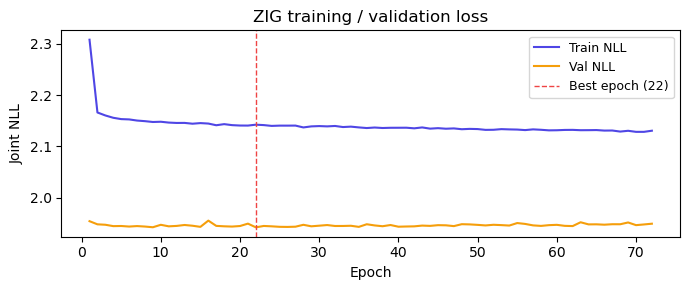

In [10]:
# ── Loss curve ────────────────────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 3))
    epochs = range(1, len(history["train"]) + 1)
    ax.plot(epochs, history["train"], label="Train NLL", color="#4f46e5")

    if "val" in history:
        ax.plot(epochs, history["val"], label="Val NLL", color="#f59e0b")
        best = history.get("best_epoch")
        if best:
            ax.axvline(best, color="#ef4444", linestyle="--", linewidth=1,
                       label=f"Best epoch ({best})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Joint NLL")
    ax.set_title("ZIG training / validation loss")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available; skipping loss curve plot.")

In [11]:
# ── Monte Carlo simulation ────────────────────────────────────────────────────
# Use 50 realisations for speed here; set n_simulations=1000 for paper-equivalent runs
occ_sim, int_sim = monte_carlo_simulate(
    model,
    doy_sequence=np.arange(1, 365 * 80 + 1),
    n_lags=N_LAGS,
    n_int_lags=N_INT_LAGS,
    n_simulations=50,
    device=DEVICE,
)
print(f"occ_sim shape: {occ_sim.shape}  |  int_sim shape: {int_sim.shape}")

occ_sim shape: (50, 29200)  |  int_sim shape: (50, 29200)


(0.0, 3000.0)

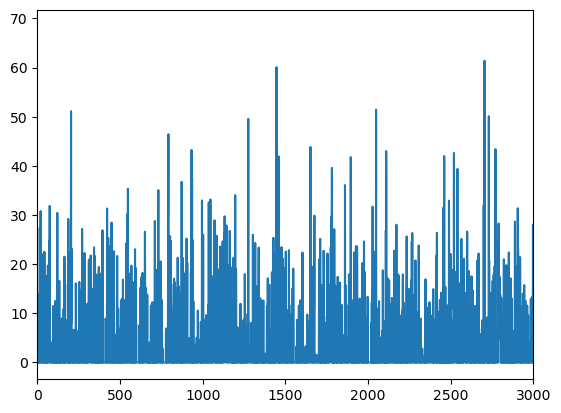

In [12]:
plt.plot(int_sim[0,:])
plt.xlim(0,3000)

Occurrence ECE = 0.0177  (0 = perfect; < 0.05 = good)


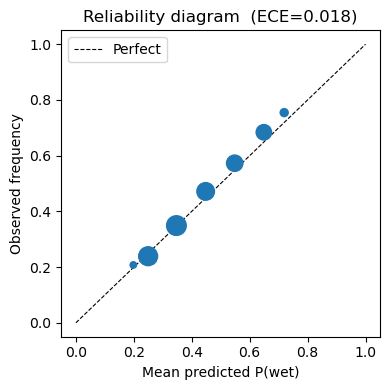

In [13]:
# ── Calibration: occurrence reliability ──────────────────────────────────────
model.eval()
prob_pred = model.p_wet(x).numpy()
centres, freqs, counts = reliability_diagram(prob_pred, y_full.numpy())
ece = expected_calibration_error(centres, freqs, counts)
print(f"Occurrence ECE = {ece:.4f}  (0 = perfect; < 0.05 = good)")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Perfect")
    ax.scatter(centres, freqs, s=counts / counts.max() * 200, zorder=3)
    ax.set_xlabel("Mean predicted P(wet)")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"Reliability diagram  (ECE={ece:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

Intensity Q-Q RMSE = 0.324 mm  (0 = perfect)


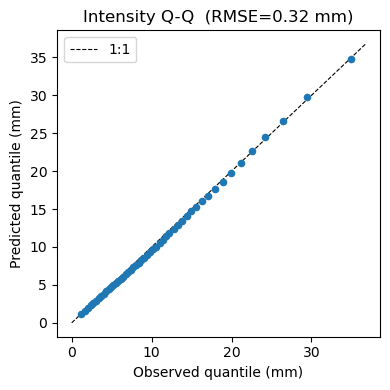

In [14]:
# ── Calibration: intensity Q-Q ────────────────────────────────────────────────
wet_mask = y_full.numpy() >= 1.0
x_wet    = x[wet_mask]
y_wet    = y_full.numpy()[wet_mask]

q_obs, q_pred = intensity_qq_stats(model, x_wet, y_wet, device=DEVICE)
qq_rmse = float(np.sqrt(np.mean((q_obs - q_pred) ** 2)))
print(f"Intensity Q-Q RMSE = {qq_rmse:.3f} mm  (0 = perfect)")

try:
    import matplotlib.pyplot as plt

    lim = max(q_obs.max(), q_pred.max()) * 1.05
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
    ax.scatter(q_obs, q_pred, s=20, zorder=3)
    ax.set_xlabel("Observed quantile (mm)")
    ax.set_ylabel("Predicted quantile (mm)")
    ax.set_title(f"Intensity Q-Q  (RMSE={qq_rmse:.2f} mm)")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

In [15]:
# ── Annual metrics ────────────────────────────────────────────────────────────
int_obs_full = y_full.numpy()           # already 0 on dry days
occ_obs_full = (int_obs_full >= 1.0).astype(np.float32)

metrics = annual_metrics(
    occ_sim, int_sim,
    occ_obs=occ_obs_full,
    int_obs=int_obs_full,
)
print("\nAnnual metrics  (obs vs. 50-member ensemble mean ± 1σ):")
for k, v in metrics.items():
    print(
        f"  {k}: obs={v['obs']:7.1f}  "
        f"sim={v['sim_mean']:7.1f} ± {v['sim_std']:.1f}"
    )


Annual metrics  (obs vs. 50-member ensemble mean ± 1σ):
  OCC: obs=  162.2  sim=  153.5 ± 1.6
  SII: obs=   11.3  sim=   10.9 ± 0.1
  TOT: obs= 1832.4  sim= 1668.3 ± 25.3


## 9. Potential Predictable Variance (PPV)

Replicates **Equation 1** from Anderson et al. (2016):

$$\mathrm{PPV(var)} = \frac{\sigma^2_{\mathrm{obs}} - \overline{\sigma^2_{\mathrm{sim}}}}{\sigma^2_{\mathrm{obs}}}$$

where

- $\sigma^2_{\mathrm{obs}}$ — observed year-to-year variance in the annual metric (OCC, SII, or TOT) across the full station record;
- $\sigma^2_{\mathrm{sim}}(n)$ — year-to-year variance of the *n*-th simulated ensemble member over an identical time window;
- $\overline{\sigma^2_{\mathrm{sim}}}$ — **mean of the per-member variances** (the mean is taken *after* the variance calculation, not before).

PPV = 1 means all observed inter-annual variance is potentially predictable; PPV = 0 means none; negative values indicate the stochastic model produces *more* variance than observed.

In [16]:
def compute_annual_metrics_ts(
    occ: np.ndarray,
    intensity: np.ndarray,
    days_per_year: int = 365,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute per-year OCC, SII, TOT for a single daily time series.

    Parameters
    ----------
    occ : (T,) binary occurrence (0/1)
    intensity : (T,) intensity in mm (0 on dry days)
    days_per_year : length of one annual window

    Returns
    -------
    ann_occ : (n_years,)  occurrence count per year
    ann_sii : (n_years,)  simple intensity index (mm event^-1) per year
    ann_tot : (n_years,)  total accumulation (mm yr^-1) per year
    """
    n_years = len(occ) // days_per_year
    occ = np.asarray(occ, dtype=np.float32)
    intensity = np.asarray(intensity, dtype=np.float32)

    ann_occ = np.empty(n_years, dtype=np.float64)
    ann_sii = np.empty(n_years, dtype=np.float64)
    ann_tot = np.empty(n_years, dtype=np.float64)

    for y in range(n_years):
        sl = slice(y * days_per_year, (y + 1) * days_per_year)
        o = occ[sl]
        i = intensity[sl]
        ann_occ[y] = o.sum()
        ann_tot[y] = i.sum()
        ann_sii[y] = float(i.sum() / o.sum()) if o.sum() > 0 else 0.0

    return ann_occ, ann_sii, ann_tot


def compute_ppv(
    occ_obs: np.ndarray,
    int_obs: np.ndarray,
    occ_sim: np.ndarray,
    int_sim: np.ndarray,
    days_per_year: int = 365,
) -> dict:
    """Compute PPV for OCC, SII, and TOT per Anderson et al. (2016) Eq. 1.

    The ensemble-mean variance is computed AFTER the per-member variance
    calculation (i.e., var first, then mean across members), matching the
    paper's description of the overbar in Eq. 1.

    Parameters
    ----------
    occ_obs : (T_obs,)    observed binary occurrence
    int_obs : (T_obs,)    observed intensity, mm (0 on dry days)
    occ_sim : (S, T_sim)  simulated binary occurrence, S ensemble members
    int_sim : (S, T_sim)  simulated intensity, mm (0 on dry days)
    days_per_year : days in one annual window

    Returns
    -------
    dict keyed by "OCC", "SII", "TOT"; each entry contains:
        var_obs        : float  observed inter-annual variance
        var_sim_each   : (S,)   per-member inter-annual variance
        mean_var_sim   : float  ensemble-mean variance (mean of per-member vars)
        ppv            : float  PPV scalar
        ann_obs        : (n_years,) observed annual values (for plotting)
        ann_sim        : (S, n_years_sim) simulated annual values (for plotting)
    """
    # ── Observed annual metrics ────────────────────────────────────────────────
    ann_occ_obs, ann_sii_obs, ann_tot_obs = compute_annual_metrics_ts(
        occ_obs, int_obs, days_per_year
    )
    var_obs = {
        "OCC": float(np.var(ann_occ_obs, ddof=1)),
        "SII": float(np.var(ann_sii_obs, ddof=1)),
        "TOT": float(np.var(ann_tot_obs, ddof=1)),
    }
    ann_obs = {"OCC": ann_occ_obs, "SII": ann_sii_obs, "TOT": ann_tot_obs}

    # ── Per-member simulated annual metrics ────────────────────────────────────
    S = occ_sim.shape[0]
    n_years_sim = occ_sim.shape[1] // days_per_year

    var_sim_each = {k: np.empty(S, dtype=np.float64) for k in ("OCC", "SII", "TOT")}
    ann_sim = {
        k: np.empty((S, n_years_sim), dtype=np.float64) for k in ("OCC", "SII", "TOT")
    }

    for s in range(S):
        ann_occ_s, ann_sii_s, ann_tot_s = compute_annual_metrics_ts(
            occ_sim[s], int_sim[s], days_per_year
        )
        # Variance of annual values for this member (mean BEFORE var would be wrong)
        var_sim_each["OCC"][s] = float(np.var(ann_occ_s, ddof=1))
        var_sim_each["SII"][s] = float(np.var(ann_sii_s, ddof=1))
        var_sim_each["TOT"][s] = float(np.var(ann_tot_s, ddof=1))
        ann_sim["OCC"][s] = ann_occ_s
        ann_sim["SII"][s] = ann_sii_s
        ann_sim["TOT"][s] = ann_tot_s

    # ── Mean of per-member variances (Eq. 1 overbar) ──────────────────────────
    results = {}
    for key in ("OCC", "SII", "TOT"):
        mean_var_sim = float(var_sim_each[key].mean())
        v_obs = var_obs[key]
        ppv = (v_obs - mean_var_sim) / v_obs if v_obs > 0 else float("nan")
        results[key] = {
            "var_obs": v_obs,
            "var_sim_each": var_sim_each[key],
            "mean_var_sim": mean_var_sim,
            "ppv": ppv,
            "ann_obs": ann_obs[key],
            "ann_sim": ann_sim[key],
        }

    return results


In [17]:
# ── Assemble observed occurrence from the intensity record ─────────────────────
occ_obs_full = (int_obs >= 1.0).astype(np.float32)  # already computed above

# occ_sim / int_sim come from cell 19 (50-member MC ensemble)
ppv_results = compute_ppv(
    occ_obs=occ_obs_full,
    int_obs=int_obs,
    occ_sim=occ_sim,
    int_sim=int_sim,
    days_per_year=365,
)

print("Anderson et al. (2016) Eq. 1 — Potential Predictable Variance")
print("=" * 58)
print(f"{'Metric':<6}  {'σ²_obs':>10}  {'mean(σ²_sim)':>12}  {'PPV':>8}")
print("-" * 58)
for key, d in ppv_results.items():
    print(
        f"{key:<6}  {d['var_obs']:>10.3f}  "
        f"{d['mean_var_sim']:>12.3f}  {d['ppv']:>8.3f}"
    )
print()
print(
    "Note: PPV > 0 → observed variance exceeds stochastic baseline\n"
    "      PPV ≤ 0 → no detectable signal above weather noise"
)


Anderson et al. (2016) Eq. 1 — Potential Predictable Variance
Metric      σ²_obs  mean(σ²_sim)       PPV
----------------------------------------------------------
OCC       4311.547       231.708     0.946
SII          7.345         0.618     0.916
TOT     1360488.841     57128.668     0.958

Note: PPV > 0 → observed variance exceeds stochastic baseline
      PPV ≤ 0 → no detectable signal above weather noise


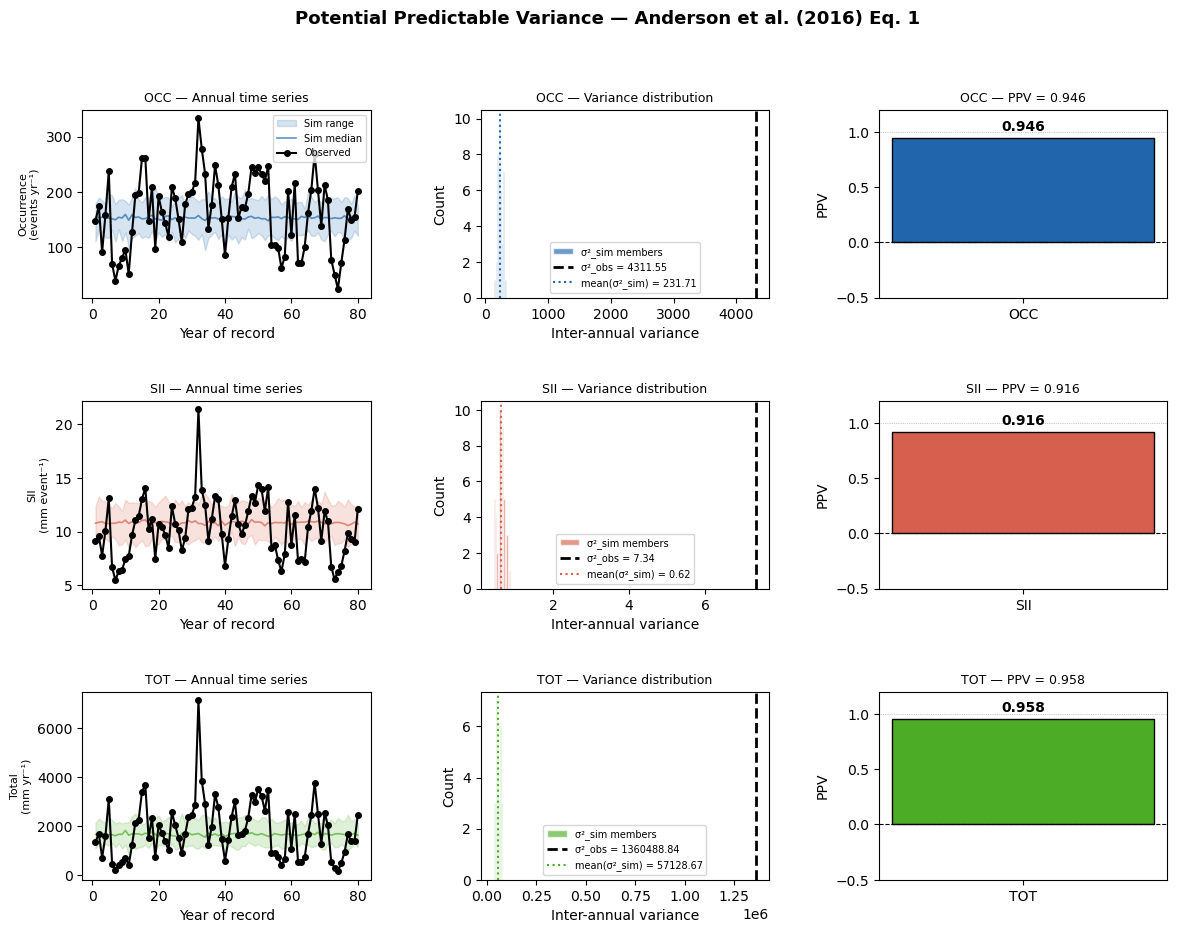

Figure saved to figures/ppv_anderson2016_eq1.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

LABELS = {"OCC": "Occurrence\n(events yr⁻¹)", "SII": "SII\n(mm event⁻¹)", "TOT": "Total\n(mm yr⁻¹)"}
COLORS = {"OCC": "#2166ac", "SII": "#d6604d", "TOT": "#4dac26"}

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "Potential Predictable Variance — Anderson et al. (2016) Eq. 1",
    fontsize=13, fontweight="bold", y=0.98,
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

years_obs = np.arange(1, len(ppv_results["OCC"]["ann_obs"]) + 1)
years_sim = np.arange(1, ppv_results["OCC"]["ann_sim"].shape[1] + 1)

for row, key in enumerate(("OCC", "SII", "TOT")):
    d = ppv_results[key]
    color = COLORS[key]

    # ── Left: annual time series ───────────────────────────────────────────────
    ax_ts = fig.add_subplot(gs[row, 0])
    sim_lo = d["ann_sim"].min(axis=0)
    sim_hi = d["ann_sim"].max(axis=0)
    sim_med = np.median(d["ann_sim"], axis=0)

    ax_ts.fill_between(years_sim, sim_lo, sim_hi, alpha=0.18, color=color, label="Sim range")
    ax_ts.plot(years_sim, sim_med, color=color, lw=1.2, alpha=0.7, label="Sim median")
    ax_ts.plot(years_obs, d["ann_obs"], "k-o", ms=4, lw=1.5, label="Observed")
    ax_ts.set_xlabel("Year of record")
    ax_ts.set_ylabel(LABELS[key], fontsize=8)
    ax_ts.set_title(f"{key} — Annual time series", fontsize=9)
    if row == 0:
        ax_ts.legend(fontsize=7, loc="upper right")

    # ── Middle: σ²_sim distribution vs σ²_obs ─────────────────────────────────
    ax_var = fig.add_subplot(gs[row, 1])
    ax_var.hist(
        d["var_sim_each"], bins=12, color=color, alpha=0.65,
        edgecolor="white", label="σ²_sim members"
    )
    ax_var.axvline(
        d["var_obs"], color="black", lw=2.0, ls="--", label=f"σ²_obs = {d['var_obs']:.2f}"
    )
    ax_var.axvline(
        d["mean_var_sim"], color=color, lw=1.5, ls=":",
        label=f"mean(σ²_sim) = {d['mean_var_sim']:.2f}"
    )
    ax_var.set_xlabel("Inter-annual variance")
    ax_var.set_ylabel("Count")
    ax_var.set_title(f"{key} — Variance distribution", fontsize=9)
    ax_var.legend(fontsize=7)

    # ── Right: PPV bar ─────────────────────────────────────────────────────────
    ax_ppv = fig.add_subplot(gs[row, 2])
    ppv_val = d["ppv"]
    bar_color = color if ppv_val >= 0 else "#999999"
    ax_ppv.bar([key], [ppv_val], color=bar_color, edgecolor="black", width=0.4)
    ax_ppv.axhline(0, color="black", lw=0.8, ls="--")
    ax_ppv.axhline(1, color="black", lw=0.5, ls=":", alpha=0.4)
    ax_ppv.set_ylim(-0.5, 1.2)
    ax_ppv.set_ylabel("PPV")
    ax_ppv.set_title(f"{key} — PPV = {ppv_val:.3f}", fontsize=9)
    ax_ppv.text(
        0, ppv_val + (0.04 if ppv_val >= 0 else -0.08),
        f"{ppv_val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

plt.savefig("figures/ppv_anderson2016_eq1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/ppv_anderson2016_eq1.png")


### 9b. Normalized PPV — significance testing (Anderson et al. 2016 Eqs. 7–8)

Raw PPV from Eq. 1 is bounded on $(-\infty, 1]$.  To assess statistical significance, the paper builds a **null distribution** by applying the same formula *within* the stochastic ensemble (each member acting as its own "observed" record):

$$\mathrm{PPV_{sim}}(n) = \frac{\sigma^2_{\mathrm{sim}}(n) - \overline{\sigma^2_{\mathrm{sim}}}}{\sigma^2_{\mathrm{sim}}(n)} \qquad \text{(Eq. 7)}$$

The **90th percentile** of $\{\mathrm{PPV_{sim}}(n)\}$ is the one-sided $p < 0.10$ threshold.  Observed PPV is then **normalized** by that threshold:

$$\widetilde{\mathrm{PPV}} = \frac{\mathrm{PPV_{obs}}}{\mathrm{PPV_{sim,\,p=0.10}}}$$

$\widetilde{\mathrm{PPV}} > 1$ → statistically significant at $p < 0.10$.  The paper's maps color-code values from 1–4+; stations below the threshold appear as grey dots.

In [19]:
def compute_normalized_ppv(ppv_results: dict) -> dict:
    """Normalize PPV by the p=0.10 significance threshold (Anderson et al. Eq. 7).

    For each ensemble member n, the within-ensemble PPV is:

        PPV_sim(n) = (sigma2_sim(n) - mean(sigma2_sim)) / sigma2_sim(n)

    The 90th percentile of this null distribution is the directional p < 0.10
    threshold.  Normalized PPV = PPV_obs / threshold; values > 1 are
    statistically significant.

    Parameters
    ----------
    ppv_results : dict returned by compute_ppv (must contain "var_sim_each",
                  "mean_var_sim", and "ppv" for each metric key)

    Returns
    -------
    Augmented dict with three new keys per metric:
        ppv_sim_each   : (S,) null PPV for each ensemble member (Eq. 7)
        threshold_p10  : float  90th-percentile significance threshold
        ppv_normalized : float  normalized PPV (> 1 = significant at p < 0.10)
    """
    results = {}
    for key, d in ppv_results.items():
        var_sim_each = d["var_sim_each"]   # (S,) per-member variances
        mean_var_sim = d["mean_var_sim"]   # scalar ensemble-mean variance

        # Eq. 7: treat each member as the "observation" against the ensemble mean
        # Guard against zero-variance members (rare edge case with small ensembles)
        # by pre-substituting 1.0 in the denominator before masking — avoids
        # RuntimeWarning from numpy evaluating both np.where branches eagerly.
        safe_mask = var_sim_each > 0
        safe_denom = np.where(safe_mask, var_sim_each, 1.0)
        ppv_sim_each = np.where(
            safe_mask,
            (var_sim_each - mean_var_sim) / safe_denom,
            np.nan,
        )

        # One-sided p < 0.10 threshold = 90th percentile of null distribution
        threshold_p10 = float(np.nanpercentile(ppv_sim_each, 90))

        # Normalized PPV; NaN if threshold is non-positive (degenerate ensemble)
        if threshold_p10 > 0:
            ppv_norm = d["ppv"] / threshold_p10
        else:
            ppv_norm = float("nan")

        results[key] = {
            **d,
            "ppv_sim_each": ppv_sim_each,
            "threshold_p10": threshold_p10,
            "ppv_normalized": ppv_norm,
        }

    return results


In [20]:
# ppv_results was computed in the cell above (Section 9 raw PPV)
ppv_norm_results = compute_normalized_ppv(ppv_results)

print("Normalized PPV — Anderson et al. (2016) significance framework")
print("=" * 66)
print(
    f"  {'Metric':<6}  {'PPV_obs':>8}  {'threshold':>10}"
    f"  {'Norm. PPV':>10}  {'Significant?':>12}"
)
print("  " + "-" * 56)
for key, d in ppv_norm_results.items():
    sig = "YES (p<0.10)" if d["ppv_normalized"] > 1 else "no"
    print(
        f"  {key:<6}  {d['ppv']:>8.3f}  {d['threshold_p10']:>10.4f}"
        f"  {d['ppv_normalized']:>10.2f}  {sig:>12}"
    )
print()
print(
    "  Normalized PPV > 1 → observed variance significantly exceeds\n"
    "  the stochastic baseline at the directional p < 0.10 level.\n"
    "  Note: the ensemble here is 50 members (paper uses 1000); the\n"
    "  threshold estimate stabilises with larger ensembles."
)


Normalized PPV — Anderson et al. (2016) significance framework
  Metric   PPV_obs   threshold   Norm. PPV  Significant?
  --------------------------------------------------------
  OCC        0.946      0.2000        4.73  YES (p<0.10)
  SII        0.916      0.1697        5.40  YES (p<0.10)
  TOT        0.958      0.1926        4.97  YES (p<0.10)

  Normalized PPV > 1 → observed variance significantly exceeds
  the stochastic baseline at the directional p < 0.10 level.
  Note: the ensemble here is 50 members (paper uses 1000); the
  threshold estimate stabilises with larger ensembles.


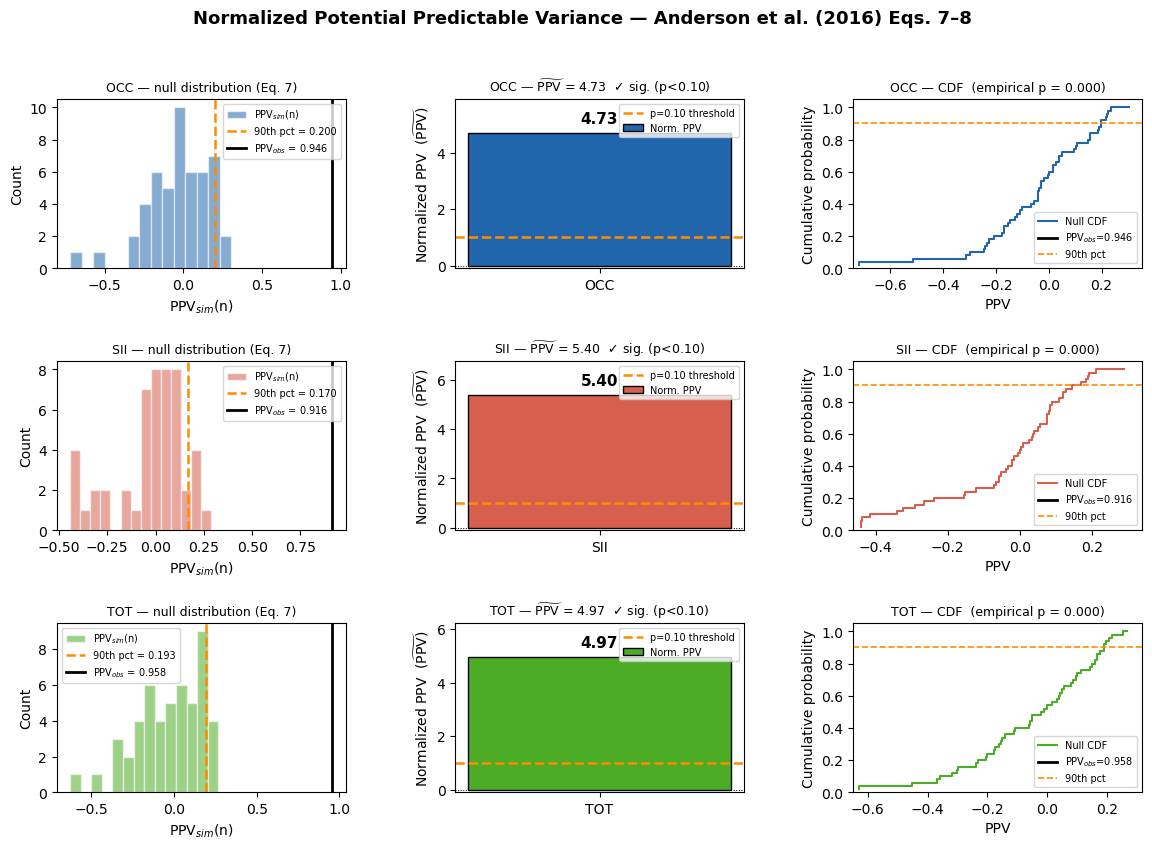

Figure saved to figures/ppv_normalized_anderson2016.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

COLORS = {"OCC": "#2166ac", "SII": "#d6604d", "TOT": "#4dac26"}

fig = plt.figure(figsize=(14, 9))
fig.suptitle(
    "Normalized Potential Predictable Variance — Anderson et al. (2016) Eqs. 7–8",
    fontsize=13, fontweight="bold", y=0.98,
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

for row, key in enumerate(("OCC", "SII", "TOT")):
    d = ppv_norm_results[key]
    color = COLORS[key]

    # ── Left: null PPV distribution vs observed PPV ────────────────────────────
    ax_null = fig.add_subplot(gs[row, 0])
    ppv_sim = d["ppv_sim_each"]
    thresh  = d["threshold_p10"]
    ppv_obs = d["ppv"]

    ax_null.hist(
        ppv_sim[~np.isnan(ppv_sim)], bins=14,
        color=color, alpha=0.55, edgecolor="white", label="PPV$_{sim}$(n)",
    )
    ax_null.axvline(
        thresh, color="darkorange", lw=1.8, ls="--",
        label=f"90th pct = {thresh:.3f}",
    )
    ax_null.axvline(
        ppv_obs, color="black", lw=2.0, ls="-",
        label=f"PPV$_{{obs}}$ = {ppv_obs:.3f}",
    )
    ax_null.set_xlabel("PPV$_{sim}$(n)")
    ax_null.set_ylabel("Count")
    ax_null.set_title(f"{key} — null distribution (Eq. 7)", fontsize=9)
    ax_null.legend(fontsize=7)

    # ── Middle: normalized PPV bar with significance line ─────────────────────
    ax_norm = fig.add_subplot(gs[row, 1])
    ppv_n = d["ppv_normalized"]
    bar_color = color if ppv_n > 1 else "#aaaaaa"
    ax_norm.bar([key], [ppv_n], color=bar_color, edgecolor="black", width=0.45,
                label="Norm. PPV")
    ax_norm.axhline(1.0, color="darkorange", lw=1.8, ls="--", label="p=0.10 threshold")
    ax_norm.axhline(0.0, color="black", lw=0.7, ls=":")
    ymax = max(ppv_n * 1.25, 1.5)
    ax_norm.set_ylim(-0.1, ymax)
    ax_norm.set_ylabel(r"Normalized PPV  ($\widetilde{\mathrm{PPV}}$)")
    sig_str = f"✓ sig. (p<0.10)" if ppv_n > 1 else "✗ not sig."
    ax_norm.set_title(
        rf"{key} — $\widetilde{{\mathrm{{PPV}}}}$ = {ppv_n:.2f}  {sig_str}", fontsize=9
    )
    ax_norm.text(
        0, ppv_n + 0.04 * ymax, f"{ppv_n:.2f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
    ax_norm.legend(fontsize=7)

    # ── Right: CDF of null vs observed PPV ────────────────────────────────────
    ax_cdf = fig.add_subplot(gs[row, 2])
    sorted_null = np.sort(ppv_sim[~np.isnan(ppv_sim)])
    cdf = np.arange(1, len(sorted_null) + 1) / len(sorted_null)
    ax_cdf.step(sorted_null, cdf, color=color, lw=1.5, label="Null CDF")
    ax_cdf.axvline(
        ppv_obs, color="black", lw=2.0, ls="-", label=f"PPV$_{{obs}}$={ppv_obs:.3f}"
    )
    ax_cdf.axhline(0.90, color="darkorange", lw=1.2, ls="--", label="90th pct")
    # Mark empirical p-value: fraction of null exceeding ppv_obs
    p_val = float((sorted_null >= ppv_obs).mean())
    ax_cdf.set_xlabel("PPV")
    ax_cdf.set_ylabel("Cumulative probability")
    ax_cdf.set_title(
        f"{key} — CDF  (empirical p = {p_val:.3f})", fontsize=9
    )
    ax_cdf.set_xlim(sorted_null.min() - 0.02, min(sorted_null.max() + 0.05, 1.02))
    ax_cdf.set_ylim(0, 1.05)
    ax_cdf.legend(fontsize=7)

plt.savefig("figures/ppv_normalized_anderson2016.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/ppv_normalized_anderson2016.png")
